# Data Preprocessing and Feature Engineering in Machine Learning
## Adult Dataset Analysis with Visible Outputs

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from scipy.stats import skew
import warnings
warnings.filterwarnings("ignore")

# Load Dataset
df = pd.read_csv('adult_with_headers.csv')

print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:

print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe(include='all'))


Column Names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

Data Types:
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object

Missing Values:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Summary Statistics:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [4]:

# Replace ? with NaN
df.replace(' ?', np.nan, inplace=True)

# Fill Missing Values
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


In [5]:

# Scaling Techniques

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Standard Scaling
standard_scaler = StandardScaler()
standard_scaled = standard_scaler.fit_transform(df[num_cols])

print("Standard Scaled Output:")
display(pd.DataFrame(standard_scaled, columns=num_cols).head())

# Min-Max Scaling
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(df[num_cols])

print("Min-Max Scaled Output:")
display(pd.DataFrame(minmax_scaled, columns=num_cols).head())

print("Standard Scaling works well for normally distributed data.")
print("Min-Max Scaling is useful for neural networks and bounded data.")


Standard Scaled Output:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


Min-Max Scaled Output:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


Standard Scaling works well for normally distributed data.
Min-Max Scaling is useful for neural networks and bounded data.


In [6]:

# Encoding Techniques

cat_cols = df.select_dtypes(include='object').columns

# One-Hot Encoding
one_hot_cols = [col for col in cat_cols if df[col].nunique() < 5]

df_encoded = pd.get_dummies(df, columns=one_hot_cols)

print("One-Hot Encoded Columns:")
print(one_hot_cols)

# Label Encoding
label_cols = [col for col in cat_cols if df[col].nunique() >= 5]

le = LabelEncoder()

for col in label_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("\nLabel Encoded Columns:")
print(label_cols)

display(df_encoded.head())

print("One-Hot Encoding avoids ordinal relationships but increases dimensions.")
print("Label Encoding is memory efficient but may create false ordering.")


One-Hot Encoded Columns:
['sex', 'income']

Label Encoded Columns:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,39,6,77516,9,13,4,0,1,4,2174,0,40,38,False,True,True,False
1,50,5,83311,9,13,2,3,0,4,0,0,13,38,False,True,True,False
2,38,3,215646,11,9,0,5,1,4,0,0,40,38,False,True,True,False
3,53,3,234721,1,7,2,5,0,2,0,0,40,38,False,True,True,False
4,28,3,338409,9,13,2,9,5,2,0,0,40,4,True,False,True,False


One-Hot Encoding avoids ordinal relationships but increases dimensions.
Label Encoding is memory efficient but may create false ordering.


New Features:


,capital_total,hours_per_age
0,2174,1.000000
1,0,0.254902
2,0,1.025641
3,0,0.740741
4,0,1.379310


Skewness Before Transformation: 1.4469134351423287
Skewness After Transformation: -0.8424221351741549


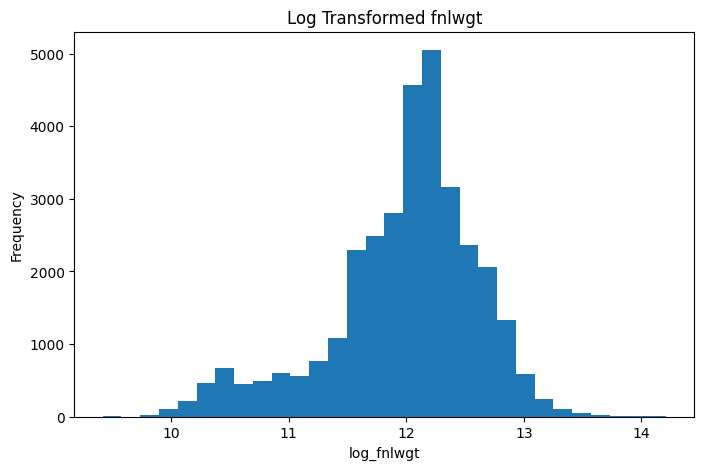

In [7]:

# Feature Engineering

# New Features
df_encoded['capital_total'] = df['capital_gain'] + df['capital_loss']
df_encoded['hours_per_age'] = df['hours_per_week'] / (df['age'] + 1)

print("New Features:")
display(df_encoded[['capital_total', 'hours_per_age']].head())

# Log Transformation
df_encoded['log_fnlwgt'] = np.log1p(df['fnlwgt'])

print("Skewness Before Transformation:", skew(df['fnlwgt']))
print("Skewness After Transformation:", skew(df_encoded['log_fnlwgt']))

plt.figure(figsize=(8,5))
plt.hist(df_encoded['log_fnlwgt'], bins=30)
plt.title("Log Transformed fnlwgt")
plt.xlabel("log_fnlwgt")
plt.ylabel("Frequency")
plt.show()


In [8]:

# Isolation Forest

iso = IsolationForest(contamination=0.05, random_state=42)

outliers = iso.fit_predict(df_encoded.select_dtypes(include=['int64', 'float64']))

df_encoded['outlier'] = outliers

print("Outlier Counts:")
print(df_encoded['outlier'].value_counts())

clean_df = df_encoded[df_encoded['outlier'] == 1]

print("Shape Before Removing Outliers:", df_encoded.shape)
print("Shape After Removing Outliers:", clean_df.shape)

print("Outliers can negatively affect model performance.")


Outlier Counts:
outlier
 1    30933
-1     1628
Name: count, dtype: int64
Shape Before Removing Outliers: (32561, 21)
Shape After Removing Outliers: (30933, 21)
Outliers can negatively affect model performance.


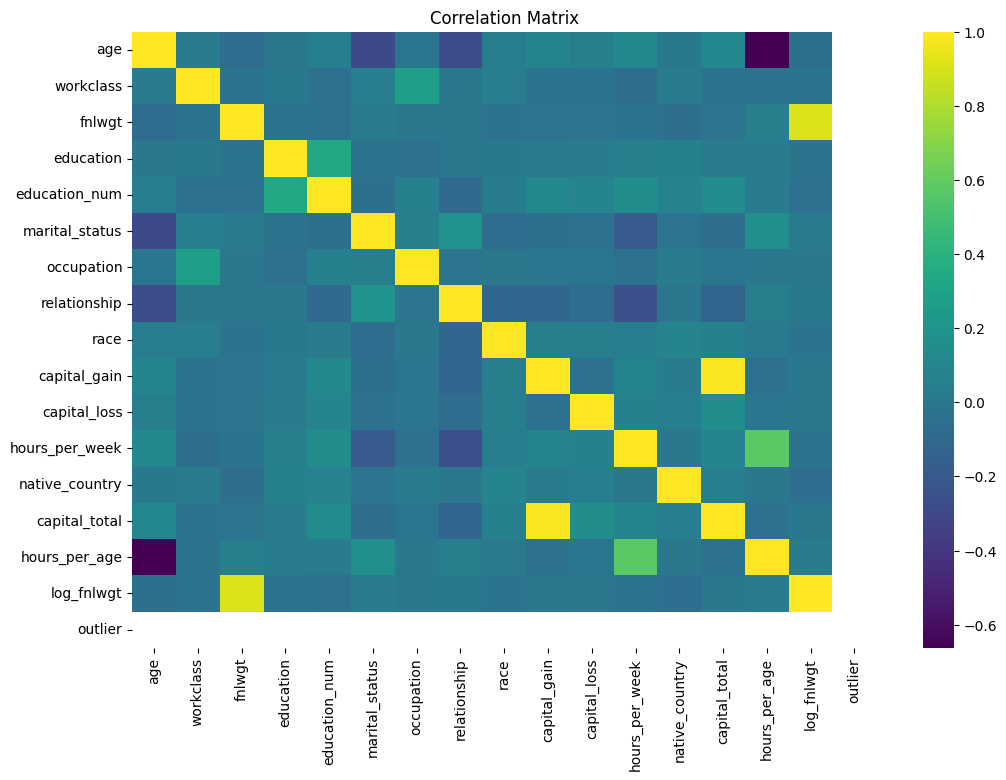

Correlation matrix shows linear relationships.
PPS Score can detect both linear and non-linear relationships.


In [9]:

# Correlation Matrix

corr = clean_df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='viridis')
plt.title("Correlation Matrix")
plt.show()

print("Correlation matrix shows linear relationships.")
print("PPS Score can detect both linear and non-linear relationships.")


In [10]:

print("Assignment Completed Successfully!")


Assignment Completed Successfully!



# PPS (Predictive Power Score) Analysis

Predictive Power Score (PPS) measures the predictive relationship between features and target variables.

Unlike correlation, PPS can detect both linear and non-linear relationships.


In [ ]:

# Install PPS Library

# pip install ppscore


In [ ]:

# Import PPS Library

import ppscore as pps


In [ ]:

# Calculate PPS Matrix

pps_matrix = pps.matrix(df)

print(pps_matrix.head())


In [ ]:

# PPS Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

pivot_df = pps_matrix.pivot(
    columns='x',
    index='y',
    values='ppscore'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_df,
    annot=True,
    cmap='Blues'
)

plt.title('Predictive Power Score Heatmap')

plt.show()


In [ ]:

# Top Predictive Relationships

top_pps = pps_matrix.sort_values(
    by='ppscore',
    ascending=False
).head(10)

print(top_pps)



# PPS Analysis Conclusion

- PPS identifies predictive relationships between variables.
- Higher PPS values indicate stronger predictive power.
- PPS can detect non-linear relationships unlike correlation.
- PPS helps in feature selection and model improvement.
